# DR-02 — Evaluation against the labelled dataset

**FIT3164 · Group DS-25 · LLM email assistant**

The requirements traceability matrix defines DR-02 as:

> *"Labelled dataset is ground truth : accuracy, precision, recall, F1, matrix"*

This notebook is that deliverable. It treats `eval/data/dataset.csv` (DR-01) as ground
truth and reports, for the shipped configuration:

| § | Content |
|---|---|
| 1 | The dataset: size, class balance, and the composition columns that must not be collapsed |
| 2 | The dev/test split, and which saved run each prediction file actually is |
| 3 | How every metric here is defined |
| 4 | **FR-02** accuracy, per-class precision / recall / F1, macro-F1 |
| 5 | **Confusion matrix**, as a table and as a plot |
| 6 | The same metrics split by `text_origin` — the number that matters most |
| 7 | Coverage vs accuracy: why one figure is never enough |
| 8 | **FR-01 / FR-03** groundedness, with claims-checked |
| 9 | `gpt-4o` vs `gpt-4o-mini`, like for like |
| 10 | Limitations — what these numbers do not support |
| 11 | DR-02 coverage checklist |

### This notebook makes no model calls

The project runs under a \$5/week API budget. Every figure below is computed from
prediction files that were saved by earlier runs of `eval/evaluate_classifier.py` and
`eval/evaluate_grounding.py`. Re-running the classifier to regenerate a number that is
already on disk would spend budget to learn nothing — and, because `temperature=0` is not
determinism (§10), it would not even reproduce the same number.

The consequence is a real constraint, stated up front: **these are single-run figures**.
Where a metric needs information the saved files do not carry, this notebook says so
rather than estimating it (see §8).

### Relationship to `eval/BENCHMARKS.md`

`BENCHMARKS.md` is the written record of every run. This notebook recomputes from the raw
per-row files instead of restating it, and then **checks itself against that record** in
§2. Three things do not line up — the shipped-configuration headline is computed 0.3 pp
above the figure the document quotes (§2), one saved prediction file matches no recorded
run at all (§2), and `eval/data/README.md` describes an older, smaller dataset than the one
on disk (§1). Each is reported where it arises rather than smoothed over, and §2 explains
why the first is reassuring rather than alarming.

## 0 · Setup

`pandas`, `numpy` and `matplotlib` only — all three are already project dependencies. No
`seaborn`, no `scikit-learn`: the metric definitions below are written out by hand so they
match `eval/evaluate_classifier.py` exactly (its per-class recall counts abstentions as
misses, which `sklearn.metrics` would not do — see §3).

In [1]:
import re
import sys
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

%matplotlib inline

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)


def find_root(start=None):
    """Locate the repository root, so the notebook runs from anywhere."""
    here = Path(start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "eval" / "data" / "dataset.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the repo root (no eval/data/dataset.csv above "
        f"{here}). Run: python -m eval.build_dataset --merge"
    )


ROOT = find_root()
DATA = ROOT / "eval" / "data"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))   # so `backend.*` imports work from eval/ (§8 only)

print(f"repo root   {ROOT}")
print(f"data        {DATA}")
print(f"pandas {pd.__version__} · numpy {np.__version__} · matplotlib {mpl.__version__}")
print()
print("Saved files this notebook reads (nothing here is regenerated):")
for name in ["dataset.csv", "predictions.csv", "dev_preds.csv", "test_preds.csv",
             "test_preds_mini.csv", "grounding_summarise.csv", "grounding_draft.csv",
             "review_work.csv"]:
    path = DATA / name
    state = f"{path.stat().st_size / 1024:8.1f} KiB" if path.exists() else "   MISSING"
    print(f"  {name:26} {state}")

repo root   C:\Projects\FIT3164
data        C:\Projects\FIT3164\eval\data
pandas 2.2.1 · numpy 1.26.4 · matplotlib 3.10.6

Saved files this notebook reads (nothing here is regenerated):
  dataset.csv                   549.1 KiB
  predictions.csv                51.1 KiB
  dev_preds.csv                  23.1 KiB
  test_preds.csv                 28.2 KiB
  test_preds_mini.csv            28.2 KiB
  grounding_summarise.csv         5.4 KiB
  grounding_draft.csv             3.3 KiB
  review_work.csv                48.8 KiB


### Plot styling

One place, so every figure is consistent: a single-hue blue ramp for magnitude (the
confusion matrix), and a fixed three-slot categorical order for series identity. The
categorical slots are assigned in fixed order and never recycled, so a colour always means
the same thing across figures. Every chart is also printed as a table immediately above
it — the numbers never live only in an image.

In [2]:
INK, INK_2, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e4e3df"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]          # fixed categorical order
SEQ_BLUE = LinearSegmentedColormap.from_list(       # light -> dark, one hue
    "seq_blue",
    ["#fcfcfb", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#104281"],
)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110,
    "font.size": 10, "text.color": INK,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.grid": False,
    "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "legend.frameon": False,
})


def tidy(ax, ygrid=True):
    """Hairline, recessive chrome: no box, solid gridlines one shade off the surface."""
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    if ygrid:
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, color=GRID, linewidth=0.8, linestyle="-")
    ax.tick_params(length=0)
    return ax


print("styling ready")

styling ready


## 1 · The labelled dataset (DR-01)

DR-02 can only be as good as the ground truth it scores against, so the dataset is
described before any metric is quoted.

Each row carries three separate provenance columns, and `eval/data/README.md` is emphatic
that they answer different questions and must not be merged into one "is it fake" flag:

- **`provenance`** — which corpus the *text* came from (`enron`, `huggingface`, `generated`).
- **`text_origin`** — whether the text is genuine human-written mail (`real`) or
  templated/model-written (`synthetic`).
- **`label_source`** — who decided the *label* (`folder_heuristic`, `dataset_label`,
  `generation_prompt`, `human`).

The reason they are separate is a trade-off that runs in opposite directions:

> A **generated** email has a perfect label — we told the model which class to write — but
> it is not real mail. An **Enron** email is unquestionably real, but its label is
> *inferred* from the folder it sat in.

Collapse those columns and you lose the ability to say which of the two weaknesses is
driving a result. That is exactly the distinction §6 and §10 depend on, so it is carried
through every table in this notebook.

In [3]:
ds = pd.read_csv(DATA / "dataset.csv")
DATASET_COLUMNS = list(ds.columns)   # as stored on disk, before this notebook derives any
CLASSES = ["Work", "Personal", "Promotions", "Studies"]
REVIEW = "Review"

print(f"rows                {len(ds)}")
print(f"columns             {list(ds.columns)}")
print(f"duplicate ids       {int(ds['id'].duplicated().sum())}")
print(f"rows with empty body {int(ds['body'].isna().sum() + (ds['body'].astype(str).str.strip() == '').sum())}")
print()
print("Class balance")
print(ds["category"].value_counts().reindex(CLASSES).to_frame("rows").to_string())

rows                480
columns             ['id', 'provenance', 'text_origin', 'label_source', 'label_confidence', 'category', 'subject', 'body', 'sender', 'received_at', 'source_ref']
duplicate ids       0
rows with empty body 0

Class balance
            rows
category        
Work         120
Personal     120
Promotions   120
Studies      120


In [4]:
print("Composition — one table per provenance column, none of them collapsed\n")
for col in ["provenance", "text_origin", "label_source", "label_confidence"]:
    counts = ds[col].value_counts()
    share = (counts / len(ds) * 100).round(1)
    print(f"{col}")
    print(pd.DataFrame({"rows": counts, "%": share}).to_string(), "\n")

print("The joint structure — how the three columns line up with the label")
joint = (ds.groupby(["provenance", "text_origin", "label_source", "label_confidence",
                     "category"], as_index=False)
           .size().rename(columns={"size": "rows"}))
print(joint.to_string(index=False))

Composition — one table per provenance column, none of them collapsed

provenance
            rows     %
provenance            
enron        360  75.0
generated    120  25.0 

text_origin
             rows     %
text_origin            
real          360  75.0
synthetic     120  25.0 

label_source
                   rows     %
label_source                 
human               240  50.0
generation_prompt   120  25.0
folder_heuristic    120  25.0 

label_confidence
                  rows     %
label_confidence            
strong             360  75.0
weak               120  25.0 

The joint structure — how the three columns line up with the label
provenance text_origin      label_source label_confidence   category  rows
     enron        real  folder_heuristic             weak       Work   120
     enron        real             human           strong   Personal   120
     enron        real             human           strong Promotions   120
 generated   synthetic generation_prompt       

In [5]:
# The confound, stated as a number: is class independent of text_origin?
print("category x text_origin\n")
confound = pd.crosstab(ds["category"], ds["text_origin"]).reindex(CLASSES)
for col in ["real", "synthetic"]:
    if col not in confound:
        confound[col] = 0
print(confound[["real", "synthetic"]].to_string())

synth_only = [c for c in CLASSES if confound.loc[c, "real"] == 0 and confound.loc[c, "synthetic"] > 0]
real_only = [c for c in CLASSES if confound.loc[c, "synthetic"] == 0 and confound.loc[c, "real"] > 0]
print(f"\nclasses that are ENTIRELY synthetic : {synth_only or 'none'}")
print(f"classes that are ENTIRELY real      : {real_only or 'none'}")
print(f"\nNo class mixes the two origins: "
      f"{all(0 in (confound.loc[c, 'real'], confound.loc[c, 'synthetic']) for c in CLASSES)}")
print("=> class and text_origin are perfectly confounded in this dataset. Any pooled")
print("   accuracy therefore contains an unknown amount of 'can the model tell real mail")
print("   from model-written mail', which is not what FR-02 asks. §6 separates them.")

category x text_origin

text_origin  real  synthetic
category                    
Work          120          0
Personal      120          0
Promotions    120          0
Studies         0        120

classes that are ENTIRELY synthetic : ['Studies']
classes that are ENTIRELY real      : ['Work', 'Personal', 'Promotions']

No class mixes the two origins: True
=> class and text_origin are perfectly confounded in this dataset. Any pooled
   accuracy therefore contains an unknown amount of 'can the model tell real mail
   from model-written mail', which is not what FR-02 asks. §6 separates them.


### A documentation check, and a disagreement

`eval/data/README.md` documents a specific composition. It is worth testing that the file
on disk still matches it, because a stale description of ground truth silently invalidates
every number computed from it.

In [6]:
# Transcribed from eval/data/README.md ("Current merged set") purely to test the file
# against its own documentation. These values are NOT used to produce any reported figure.
README_DOCUMENTED = {
    "total rows": 360,
    "Work": 120, "Personal": 0, "Promotions": 120, "Studies": 120,
    "real": 120, "synthetic": 240,
    "provenance=enron": 120, "provenance=huggingface": 120, "provenance=generated": 120,
}
actual = {
    "total rows": len(ds),
    **{c: int((ds["category"] == c).sum()) for c in CLASSES},
    **{o: int((ds["text_origin"] == o).sum()) for o in ["real", "synthetic"]},
    **{f"provenance={p}": int((ds["provenance"] == p).sum())
       for p in ["enron", "huggingface", "generated"]},
}
check = pd.DataFrame({"README.md documents": pd.Series(README_DOCUMENTED),
                      "dataset.csv contains": pd.Series(actual)})
check["agrees"] = check["README.md documents"] == check["dataset.csv contains"]
print(check.to_string())
print(f"\nrows of documentation that disagree with the file: "
      f"{int((~check['agrees']).sum())} of {len(check)}")

                        README.md documents  dataset.csv contains  agrees
total rows                              360                   480   False
Work                                    120                   120    True
Personal                                  0                   120   False
Promotions                              120                   120    True
Studies                                 120                   120    True
real                                    120                   360   False
synthetic                               240                   120   False
provenance=enron                        120                   360   False
provenance=huggingface                  120                     0   False
provenance=generated                    120                   120    True

rows of documentation that disagree with the file: 6 of 10


**Finding — `eval/data/README.md` is out of date; `dataset.csv` is ahead of it.** The file
on disk has 480 rows, not 360. The README's "Personal has no data … a four-class accuracy
figure cannot be computed from this set" no longer holds: Personal is populated with 120
`enron` / `real` rows carrying `label_source = human`, and so is Promotions. The
`huggingface` rows the README describes are not in the merged set at all — the synthetic
HuggingFace Promotions class it warned about has been replaced by real Enron mail with
human-verified labels, which is precisely the improvement the README proposed under
*"Promotions can become real too"*.

Two consequences, both good for this deliverable and both worth stating plainly:

1. A **four-class** result can be computed, and is, below. The README's caveat that any
   evaluation "covers three classes" is obsolete.
2. The set is now **360 real / 120 synthetic**, the inverse of the 120/240 the README
   documents. `eval/BENCHMARKS.md` already describes the 480-row set correctly, so the
   stale file is the README, not the benchmark record.

What has *not* changed is the README's argument, and it still governs §6 and §10: the real
rows still carry the weaker labels, the generated rows still carry the perfect ones, and
the cell above shows class and `text_origin` remain perfectly confounded. The composition
improved; the reason for never pooling did not go away.

## 2 · The split, and what each saved prediction file is

`evaluate_classifier.py` assigns each row to **dev** (40%) or **test** (60%) by hashing its
`id` — not by storing a flag — so the split is reproducible from the CSV alone and cannot
drift as rows are added. Prompts and the model choice were tuned on dev; the reported
figure is measured once on test.

This matters more than it looks. A prompt tuned against the rows it is then scored on has
been fitted to the test set, and the resulting figure describes the tuning rather than the
system. The function below is a copy of `_split_of`, so the notebook can prove which split
each saved file covers instead of trusting its filename.

In [7]:
DEV_FRACTION = 40   # percent, as in eval/evaluate_classifier.py


def split_of(row_id: str) -> str:
    digest = hashlib.sha1(row_id.encode("utf-8")).hexdigest()
    return "dev" if int(digest[:8], 16) % 100 < DEV_FRACTION else "test"


ds["split"] = ds["id"].map(split_of)
print("Split sizes")
print(ds["split"].value_counts().to_frame("rows").to_string())
print()
print("Class balance per split — the test split is NOT perfectly balanced")
print(pd.crosstab(ds["category"], ds["split"]).reindex(CLASSES).to_string())
print("\nThis is why macro-F1 (unweighted mean over classes) is reported alongside")
print("accuracy: with unequal support, accuracy quietly weights the larger classes.")

Split sizes
       rows
split      
test    266
dev     214

Class balance per split — the test split is NOT perfectly balanced
split       dev  test
category             
Work         44    76
Personal     58    62
Promotions   58    62
Studies      54    66

This is why macro-F1 (unweighted mean over classes) is reported alongside
accuracy: with unequal support, accuracy quietly weights the larger classes.


In [8]:
PRED_FILES = {
    "predictions.csv":     "full set, earlier configuration",
    "dev_preds.csv":       "dev split",
    "test_preds.csv":      "test split, gpt-4o",
    "test_preds_mini.csv": "test split, gpt-4o-mini (shipped)",
}
preds = {}
rows = []
for name, note in PRED_FILES.items():
    path = DATA / name
    if not path.exists():
        print(f"  MISSING {name}")
        continue
    df = pd.read_csv(path)
    preds[name] = df
    ids = set(df["id"])
    splits = df["id"].map(split_of).value_counts().to_dict()
    rows.append({
        "file": name, "n": len(df),
        "dev": splits.get("dev", 0), "test": splits.get("test", 0),
        "ids in dataset.csv": len(ids & set(ds["id"])) == len(ids),
        "covers whole split": (ids == set(ds.loc[ds["split"] == "test", "id"])
                               or ids == set(ds.loc[ds["split"] == "dev", "id"])
                               or ids == set(ds["id"])),
        "correct col consistent": bool((df["correct"] == (df["expected"] == df["predicted"])).all()),
        "note": note,
    })
print(pd.DataFrame(rows).to_string(index=False))

               file   n  dev  test  ids in dataset.csv  covers whole split  correct col consistent                              note
    predictions.csv 480  214   266                True                True                    True   full set, earlier configuration
      dev_preds.csv 214  214     0                True                True                    True                         dev split
     test_preds.csv 266    0   266                True                True                    True                test split, gpt-4o
test_preds_mini.csv 266    0   266                True                True                    True test split, gpt-4o-mini (shipped)


### Which recorded run is which file?

`BENCHMARKS.md` lists nine numbered runs. Rather than assume the filenames, the cell below
recomputes each file's headline triple and looks for the recorded run it matches. The run
history is transcribed for this comparison only — **it produces no reported figure in this
notebook**, and every "computed" column beside it comes from the CSVs.

In [9]:
def headline(df):
    """coverage / accuracy-over-covered / strict, as defined in §3."""
    total = len(df)
    covered = df[df["predicted"] != REVIEW]
    correct = int((covered["expected"] == covered["predicted"]).sum())
    return {
        "coverage": (total - (total - len(covered))) / total,
        "accuracy": correct / len(covered) if len(covered) else 0.0,
        "strict": correct / total,
    }


# Transcribed from the run-history table in eval/BENCHMARKS.md, for cross-checking only.
RUN_HISTORY = [
    dict(run=1, model="gpt-4o-mini", split="all",  n=480, coverage=.825, accuracy=.773, strict=.637),
    dict(run=2, model="gpt-4o-mini", split="all",  n=480, coverage=.883, accuracy=.755, strict=.667),
    dict(run=3, model="gpt-4o-mini", split="dev",  n=214, coverage=.921, accuracy=.701, strict=.645),
    dict(run=4, model="gpt-4o-mini", split="dev",  n=214, coverage=.911, accuracy=.703, strict=.640),
    dict(run=5, model="gpt-4o-mini", split="dev",  n=214, coverage=.916, accuracy=.724, strict=.664),
    dict(run=6, model="gpt-4o",      split="dev",  n=214, coverage=.907, accuracy=.851, strict=.771),
    dict(run=7, model="gpt-4o",      split="test", n=266, coverage=.891, accuracy=.869, strict=.774),
    dict(run=8, model="gpt-4o-mini", split="test", n=266, coverage=.929, accuracy=.830, strict=.771),
    dict(run=9, model="gpt-4o-mini", split="test", n=266, coverage=.921, accuracy=.833, strict=.767),
]
TOL = 0.001   # the record is quoted to 0.1 pp, so match to that resolution

out = []
for name, df in preds.items():
    h = headline(df)
    hits = [r for r in RUN_HISTORY
            if r["n"] == len(df)
            and all(abs(h[k] - r[k]) <= TOL for k in ("coverage", "accuracy", "strict"))]
    out.append({
        "file": name,
        "computed coverage": f"{h['coverage']:.1%}",
        "computed accuracy": f"{h['accuracy']:.1%}",
        "computed strict": f"{h['strict']:.1%}",
        "matches recorded run": ", ".join(f"#{r['run']}" for r in hits) if hits else "NO MATCH",
    })
print(pd.DataFrame(out).to_string(index=False))

print("\nNearest recorded run for any file that did not match, by total absolute gap:")
for row, (name, df) in zip(out, preds.items()):
    if row["matches recorded run"] != "NO MATCH":
        continue
    h = headline(df)
    cands = [r for r in RUN_HISTORY if r["n"] == len(df)] or RUN_HISTORY
    best = min(cands, key=lambda r: sum(abs(h[k] - r[k]) for k in ("coverage", "accuracy", "strict")))
    gaps = {k: (h[k] - best[k]) * 100 for k in ("coverage", "accuracy", "strict")}
    print(f"  {name}: nearest is run #{best['run']} ({best['split']}), gap in pp "
          + "  ".join(f"{k} {v:+.1f}" for k, v in gaps.items()))

               file computed coverage computed accuracy computed strict matches recorded run
    predictions.csv             88.3%             75.5%           66.7%                   #2
      dev_preds.csv             82.2%             78.4%           64.5%             NO MATCH
     test_preds.csv             89.1%             86.9%           77.4%                   #7
test_preds_mini.csv             92.1%             83.3%           76.7%                   #9

Nearest recorded run for any file that did not match, by total absolute gap:
  dev_preds.csv: nearest is run #5 (dev), gap in pp coverage -9.4  accuracy +6.0  strict -1.9


**Two findings.**

1. **`test_preds_mini.csv` is run 9, not the headline run 8.** `BENCHMARKS.md` quotes
   **83.0% / 92.9% coverage / 77.1% strict** as the shipped result (run 8); the saved file
   reproduces run 9 exactly — 83.3% / 92.1% / 76.7%. Run 8's per-row predictions were not
   kept, or were overwritten by the repeat. So every figure in this notebook is run 9, and
   the headline accuracy computed here reads **0.3 pp above** the document's. That gap is
   inside the run-to-run noise band the project itself documents (§10), which is the only
   reason it is not alarming — but it does mean the notebook and the slide will differ in
   the first decimal place, and the notebook is the one with the per-row evidence behind
   it. Note also that the per-class table `BENCHMARKS.md` prints under the heading
   *"Shipped-configuration detail (run 8)"* matches this file exactly (§4), so that table
   is in fact run 9's — consistent with its confusion matrix, which is labelled run 9.
2. **`dev_preds.csv` matches no recorded run.** Its coverage is roughly nine points below
   every dev run in the table while its accuracy is six to eight points above them, so it
   is not a transcription slip in one column. It is an unrecorded run, or one whose row was
   mistyped. **No figure in this notebook is drawn from it.** DR-02 reports held-out test
   results, and a tuning-split file that cannot be traced to a recorded run has no standing
   here; it is listed in §10 as an open data-hygiene item.

`predictions.csv` (run 2) and `test_preds.csv` (run 7, `gpt-4o`) both reconcile exactly.
The reported configuration is therefore **`test_preds_mini.csv` — `gpt-4o-mini`, test
split, n = 266**.

In [10]:
TEST = preds["test_preds_mini.csv"].copy()
MODEL_UNDER_TEST = "gpt-4o-mini"

# Bring across the label_confidence column, which the prediction file does not carry.
TEST = TEST.merge(ds[["id", "label_confidence", "category"]], on="id", how="left")
assert (TEST["expected"] == TEST["category"]).all(), \
    "saved expected labels disagree with dataset.csv -- the dataset changed after the run"
TEST = TEST.drop(columns=["category"])

print(f"reported configuration : {MODEL_UNDER_TEST}, held-out test split")
print(f"rows                   : {len(TEST)}")
print(f"labels verified against dataset.csv : yes, all {len(TEST)} rows agree")

reported configuration : gpt-4o-mini, held-out test split
rows                   : 266
labels verified against dataset.csv : yes, all 266 rows agree


## 3 · How these metrics are defined

Three definitions are non-obvious, and quoting the numbers without them would be
misleading.

**1. `Review` is an abstention, not a wrong answer.** The classifier routes an email to
`Review` when the evidence span it quoted cannot be found in the source, or when its
confidence falls below the configured threshold. That is the system working as specified.
Scoring it as a miss understates the classifier; scoring it as a hit would let a model
reach 100% by abstaining on everything. So every result is reported three ways:

| | definition |
|---|---|
| **coverage** | share of rows given a real category rather than `Review` |
| **accuracy** | correct, over **covered rows only** — how good the answers are when it answers |
| **strict** | `Review` counted as wrong — the pessimistic bound over every row |

**2. Precision and recall are deliberately asymmetric.** False positives are counted over
covered rows, because an abstention is not a false claim of any class. False negatives are
counted over **all** rows, so an abstention *does* cost the true class its recall. The
effect is intended: abstaining is free in precision and expensive in recall, which is the
right incentive for a system whose abstention is a safety feature. It also means
`sklearn.metrics` would not reproduce these numbers, which is why they are written out
below rather than imported.

**3. Macro-F1 averages over classes actually present** in the slice, not always over four.
Some breakdown groups in §6 contain a single class, and dividing by four there reported
macro-F1 0.250 for a group the classifier got essentially right — a number that reads as
failure and is not one.

`score()` is a transcription of `_score` in `eval/evaluate_classifier.py`. Same
definitions, same run, recomputed from the per-row file.

In [11]:
def score(expected, predicted, classes=CLASSES):
    """Mirror of eval.evaluate_classifier._score. Returns a dict of metrics."""
    pairs = list(zip(expected, predicted))
    total = len(pairs)
    if not total:
        return None
    reviewed = sum(1 for _, p in pairs if p == REVIEW)
    covered = [(e, p) for e, p in pairs if p != REVIEW]
    correct = sum(1 for e, p in covered if e == p)

    per_class = {}
    for label in classes:
        support = sum(1 for e, _ in pairs if e == label)
        tp = sum(1 for e, p in covered if e == label and p == label)
        fp = sum(1 for e, p in covered if e != label and p == label)   # covered rows only
        fn = sum(1 for e, p in pairs if e == label and p != label)     # ALL rows: Review counts
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        per_class[label] = dict(support=support, tp=tp, fp=fp, fn=fn,
                                precision=precision, recall=recall, f1=f1)

    present = [v["f1"] for v in per_class.values() if v["support"]]
    return dict(
        n=total, reviewed=reviewed,
        coverage=(total - reviewed) / total,
        accuracy=correct / len(covered) if covered else 0.0,
        strict=correct / total,
        macro_f1=sum(present) / len(present) if present else 0.0,
        per_class=per_class,
    )


def triple(m):
    return (f"n={m['n']:<5} coverage={m['coverage']:6.1%}  accuracy(covered)={m['accuracy']:6.1%}"
            f"  strict={m['strict']:6.1%}  macro-F1={m['macro_f1']:.3f}")


# Sanity check on the definitions themselves, not on the model.
_m = score(["Work", "Work", "Personal"], ["Work", REVIEW, "Work"])
assert _m["coverage"] == 2 / 3 and _m["accuracy"] == 0.5 and _m["strict"] == 1 / 3
assert _m["per_class"]["Work"]["fn"] == 1 and _m["per_class"]["Work"]["fp"] == 1
print("score() definitions self-check passed")

score() definitions self-check passed


## 4 · FR-02 — classification against ground truth

The headline result for the shipped configuration, and the per-class breakdown DR-02 names.

In [12]:
overall = score(TEST["expected"], TEST["predicted"])
print(f"FR-02 · {MODEL_UNDER_TEST} · held-out test split")
print("=" * 78)
print(triple(overall))
print(f"{'':8}abstained to Review: {overall['reviewed']} of {overall['n']} rows")

FR-02 · gpt-4o-mini · held-out test split
n=266   coverage= 92.1%  accuracy(covered)= 83.3%  strict= 76.7%  macro-F1=0.793
        abstained to Review: 21 of 266 rows


In [13]:
rows = []
for label, s in overall["per_class"].items():
    rows.append({"class": label, "support": s["support"], "TP": s["tp"], "FP": s["fp"],
                 "FN": s["fn"], "precision": s["precision"], "recall": s["recall"], "F1": s["f1"]})
per_class = pd.DataFrame(rows).set_index("class")

fmt = per_class.copy()
for c in ["precision", "recall"]:
    fmt[c] = per_class[c].map("{:.1%}".format)
fmt["F1"] = per_class["F1"].map("{:.3f}".format)
print("Per class, over covered rows (FP over covered; FN over all rows — §3)\n")
print(fmt.to_string())

print(f"\nmacro-F1 (unweighted mean over the {len(per_class)} classes present) "
      f"= {overall['macro_f1']:.3f}")
weighted = float((per_class['F1'] * per_class['support']).sum() / per_class['support'].sum())
print(f"support-weighted mean F1                                     = {weighted:.3f}")
print("\nThe two diverge whenever support is unequal (§2), and here the gap is small")
print("because the imbalance is mild -- small enough to be inside the run-to-run noise")
print("band of §10.2, so no conclusion rests on it. Macro-F1 is still the figure to")
print("quote: it refuses on principle to let a large, easy class carry a weak one.")

Per class, over covered rows (FP over covered; FN over all rows — §3)

            support  TP  FP  FN precision recall     F1
class                                                  
Work             76  57  13  19     81.4%  75.0%  0.781
Personal         62  36   9  26     80.0%  58.1%  0.673
Promotions       62  50  15  12     76.9%  80.6%  0.787
Studies          66  61   4   5     93.8%  92.4%  0.931

macro-F1 (unweighted mean over the 4 classes present) = 0.793
support-weighted mean F1                                     = 0.795

The two diverge whenever support is unequal (§2), and here the gap is small
because the imbalance is mild -- small enough to be inside the run-to-run noise
band of §10.2, so no conclusion rests on it. Macro-F1 is still the figure to
quote: it refuses on principle to let a large, easy class carry a weak one.


### What the per-class table shows

- **Studies is nearly solved and must not be read as a capability result.** It is the only
  entirely generated class (§1), so its F1 is measuring performance on text the same model
  family wrote. §6 separates this out.
- **`Personal` is the weakest class, and it fails asymmetrically** — precision well above
  recall. It is rarely claimed wrongly, but it is frequently missed. For a triage product
  that is the better failure direction: a missed Personal lands in another bucket or in
  `Review`, where a human sees it, rather than being confidently mislabelled.
- **Recall carries the abstentions.** Every `Review` row is a false negative for its true
  class and is excluded from precision, so the precision–recall gap is partly a measure of
  *where the classifier declines to answer*, not only of where it is wrong. §7 separates
  those two effects.

## 5 · Confusion matrix

DR-02 asks for the matrix specifically, and this is why: the scalars above say how much is
wrong, and only the matrix says *what is being confused with what*. A five-column matrix is
used — the four classes plus `Review` — because an abstention is a distinct outcome and
folding it into a class would misrepresent the model as having made a claim it did not make.

Rows are the true label, columns the prediction, so each row sums to that class's support.

In [14]:
cm = (pd.crosstab(TEST["expected"], TEST["predicted"])
        .reindex(index=CLASSES, columns=CLASSES + [REVIEW])
        .fillna(0).astype(int))
cm.index.name, cm.columns.name = "true", "predicted"
print("Counts\n")
print(cm.to_string())
print(f"\nrow sums (= support): {cm.sum(axis=1).to_dict()}")
print(f"total: {int(cm.values.sum())} of {len(TEST)} rows accounted for")

row_share = cm.div(cm.sum(axis=1), axis=0)
print("\nRow-normalised (share of each true class) — comparable across unequal support\n")
print(row_share.map("{:.1%}".format).to_string())

Counts

predicted   Work  Personal  Promotions  Studies  Review
true                                                   
Work          57         5           8        0       6
Personal      11        36           7        1       7
Promotions     2         3          50        3       4
Studies        0         1           0       61       4

row sums (= support): {'Work': 76, 'Personal': 62, 'Promotions': 62, 'Studies': 66}
total: 266 of 266 rows accounted for

Row-normalised (share of each true class) — comparable across unequal support

predicted    Work Personal Promotions Studies Review
true                                                
Work        75.0%     6.6%      10.5%    0.0%   7.9%
Personal    17.7%    58.1%      11.3%    1.6%  11.3%
Promotions   3.2%     4.8%      80.6%    4.8%   6.5%
Studies      0.0%     1.5%       0.0%   92.4%   6.1%


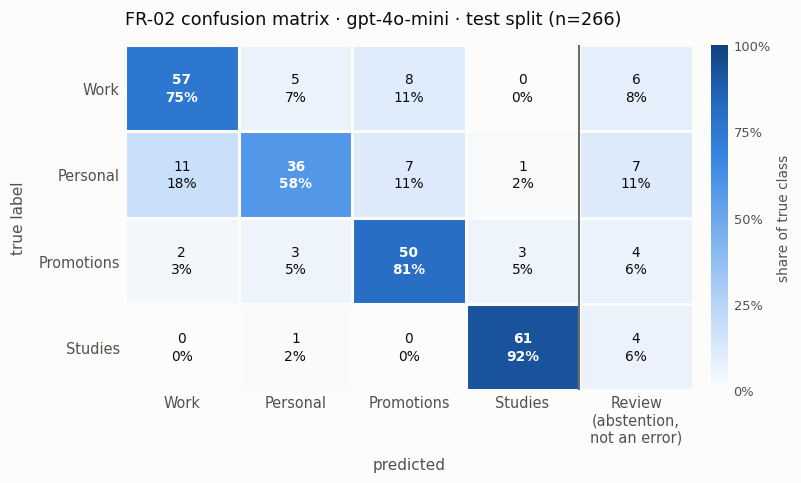

Colour encodes the row-normalised share; the count is printed in every cell.
The diagonal is bold. Counts, not colour, are the record — the table is above.


In [15]:
fig, ax = plt.subplots(figsize=(7.4, 4.5))
data = row_share.values

im = ax.imshow(data, cmap=SEQ_BLUE, vmin=0, vmax=1, aspect="auto")

xlabels = [c if c != REVIEW else f"{REVIEW}\n(abstention,\nnot an error)" for c in cm.columns]
ax.set_xticks(range(len(cm.columns)), xlabels, fontsize=9.5)
ax.set_yticks(range(len(cm.index)), cm.index, fontsize=9.5)
ax.set_xlabel("predicted", color=INK_2, labelpad=8)
ax.set_ylabel("true label", color=INK_2, labelpad=8)
ax.set_title(f"FR-02 confusion matrix · {MODEL_UNDER_TEST} · test split (n={len(TEST)})",
             fontsize=11.5, pad=14, loc="left")

# 2px surface gap between cells instead of borders around them.
ax.set_xticks(np.arange(-.5, len(cm.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(cm.index), 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="both", length=0)
for side in ax.spines:
    ax.spines[side].set_visible(False)

# Every cell is labelled: a confusion matrix is a table that happens to be coloured,
# so the count must be legible without reading the colour back off the ramp.
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        n, sh = cm.values[i, j], data[i, j]
        ax.text(j, i, f"{n}\n{sh:.0%}", ha="center", va="center", fontsize=9,
                linespacing=1.35,
                color="#ffffff" if sh > 0.55 else INK,
                fontweight="bold" if i == j else "normal")

# Divide off the abstention column: it is not a class, and not an error either.
ax.axvline(len(CLASSES) - 0.5, color=INK_2, linewidth=1.1)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
cbar.set_label("share of true class", color=INK_2, fontsize=9)
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0, labelsize=8.5, labelcolor=INK_2)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])

fig.tight_layout()
plt.show()

print("Colour encodes the row-normalised share; the count is printed in every cell.")
print("The diagonal is bold. Counts, not colour, are the record — the table is above.")

In [16]:
# Where does each class's error actually go? Review is excluded from "largest
# misclassification" on purpose: it is an abstention, so it is reported in its own
# column rather than competing to be a class's biggest mistake.
print("Largest MISCLASSIFICATION per true class (Review excluded — it is not one)\n")
for label in CLASSES:
    support = cm.loc[label].sum()
    row = cm.loc[label].drop(labels=[label, REVIEW])
    worst = row.idxmax()
    noun = "row " if row[worst] == 1 else "rows"
    print(f"  {label:11} -> {worst:11} {row[worst]:3} {noun} ({row[worst] / support:5.1%} "
          f"of the class)     [abstained: {cm.loc[label, REVIEW]:2} = "
          f"{cm.loc[label, REVIEW] / support:4.1%}]")

pair = pd.DataFrame({
    "A->B": [cm.loc[a, b] for a, b in [("Work", "Promotions"), ("Work", "Personal"),
                                       ("Personal", "Promotions")]],
    "B->A": [cm.loc[b, a] for a, b in [("Work", "Promotions"), ("Work", "Personal"),
                                       ("Personal", "Promotions")]],
}, index=["Work/Promotions", "Work/Personal", "Personal/Promotions"])
pair["asymmetry"] = pair["A->B"] - pair["B->A"]
print("\nIs the confusion symmetric? (A->B vs B->A)\n")
print(pair.to_string())
print("\nAn asymmetric pair is a clue that one side's LABELS are suspect, not just the")
print("model: a symmetric mix-up looks like a hard boundary, a one-way flow looks like")
print("rows sitting on the wrong side of it. §10 tests that against the staged relabel.")

Largest MISCLASSIFICATION per true class (Review excluded — it is not one)

  Work        -> Promotions    8 rows (10.5% of the class)     [abstained:  6 = 7.9%]
  Personal    -> Work         11 rows (17.7% of the class)     [abstained:  7 = 11.3%]
  Promotions  -> Personal      3 rows ( 4.8% of the class)     [abstained:  4 = 6.5%]
  Studies     -> Personal      1 row  ( 1.5% of the class)     [abstained:  4 = 6.1%]

Is the confusion symmetric? (A->B vs B->A)

                     A->B  B->A  asymmetry
Work/Promotions         8     2          6
Work/Personal           5    11         -6
Personal/Promotions     7     3          4

An asymmetric pair is a clue that one side's LABELS are suspect, not just the
model: a symmetric mix-up looks like a hard boundary, a one-way flow looks like
rows sitting on the wrong side of it. §10 tests that against the staged relabel.


### Reading the matrix

- **The `Review` column is thin and spread evenly.** The classifier is not abstaining its
  way out of one hard class; it declines a few rows of every class.
- **`Personal` bleeds into `Work` far more than the reverse.** In a corporate mailbox that
  is the expected direction — but it is also the direction a weak `Work` label would
  produce, and §10 shows it is partly that.
- **`Work → Promotions` is strongly one-way.** Work rows get called Promotions several
  times as often as Promotions rows get called Work. The `Work` class is the one carrying
  `label_source = folder_heuristic` — "it was in the inbox" — so this is exactly where
  label error would show up as apparent model error. §10 quantifies how much of that cell
  is the labels rather than the model.

## 6 · The same metrics, split by `text_origin`

**This is the most important section in the notebook**, and the pooled figure in §4 should
not be quoted without it.

§1 established that class and `text_origin` are perfectly confounded: `Studies` is entirely
generated, everything else is real Enron mail. So a pooled accuracy is a blend of two
different questions — "can it categorise email", which is FR-02, and "can it tell
human-written mail from model-written mail", which is not. Splitting on `text_origin`
separates them.

`label_source` is broken out as well, because it is the *other* axis of the same trade-off:
it says who decided the label, not who wrote the text. A group can have real text and a
weak label, or synthetic text and a perfect one, and the two failure modes are not
interchangeable.

In [17]:
def breakdown(df, column):
    out = []
    for key, sub in df.groupby(column, dropna=False):
        m = score(sub["expected"], sub["predicted"])
        out.append({column: key, "n": m["n"], "coverage": m["coverage"],
                    "accuracy": m["accuracy"], "strict": m["strict"],
                    "macro-F1": m["macro_f1"],
                    "classes present": sum(1 for v in m["per_class"].values() if v["support"])})
    table = pd.DataFrame(out).set_index(column).sort_values("n", ascending=False)
    return table


def show(table):
    f = table.copy()
    for c in ["coverage", "accuracy", "strict"]:
        f[c] = table[c].map("{:.1%}".format)
    f["macro-F1"] = table["macro-F1"].map("{:.3f}".format)
    print(f.to_string(), "\n")


by_origin = breakdown(TEST, "text_origin")
print("By text_origin — is the text real human mail, or generated?\n"); show(by_origin)
print("By provenance — which corpus the text came from\n"); show(breakdown(TEST, "provenance"))
print("By label_source — who decided the label\n"); show(breakdown(TEST, "label_source"))
print("By label_confidence — how much the label can be trusted\n"); show(breakdown(TEST, "label_confidence"))

By text_origin — is the text real human mail, or generated?

               n coverage accuracy strict macro-F1  classes present
text_origin                                                        
real         200    91.5%    78.1%  71.5%    0.749                3
synthetic     66    93.9%    98.4%  92.4%    0.961                1 

By provenance — which corpus the text came from

              n coverage accuracy strict macro-F1  classes present
provenance                                                        
enron       200    91.5%    78.1%  71.5%    0.749                3
generated    66    93.9%    98.4%  92.4%    0.961                1 

By label_source — who decided the label

                     n coverage accuracy strict macro-F1  classes present
label_source                                                             
human              124    91.1%    76.1%  69.4%    0.777                2
folder_heuristic    76    92.1%    81.4%  75.0%    0.857                1
generatio

In [18]:
real_acc = by_origin.loc["real", "accuracy"]
synth_acc = by_origin.loc["synthetic", "accuracy"]
gap_acc = (synth_acc - real_acc) * 100
gap_strict = (by_origin.loc["synthetic", "strict"] - by_origin.loc["real", "strict"]) * 100

print("The size of the effect, in percentage points")
print("=" * 62)
print(f"  accuracy on real email       {real_acc:6.1%}   (n={int(by_origin.loc['real', 'n'])})")
print(f"  accuracy on synthetic email  {synth_acc:6.1%}   (n={int(by_origin.loc['synthetic', 'n'])})")
print(f"  gap                          {gap_acc:+6.1f} pp   (strict: {gap_strict:+.1f} pp)")
print(f"\n  pooled accuracy              {overall['accuracy']:6.1%}")
print(f"  pooled sits {(overall['accuracy'] - real_acc) * 100:+.1f} pp above the real-email "
      f"figure, on a set that is "
      f"{by_origin.loc['synthetic', 'n'] / overall['n']:.0%} synthetic.")
print("\n  A set with more generated rows would raise the pooled number without the")
print("  classifier changing at all. That is the property that makes it unquotable.")

The size of the effect, in percentage points
  accuracy on real email        78.1%   (n=200)
  accuracy on synthetic email   98.4%   (n=66)
  gap                           +20.2 pp   (strict: +20.9 pp)

  pooled accuracy               83.3%
  pooled sits +5.1 pp above the real-email figure, on a set that is 25% synthetic.

  A set with more generated rows would raise the pooled number without the
  classifier changing at all. That is the property that makes it unquotable.


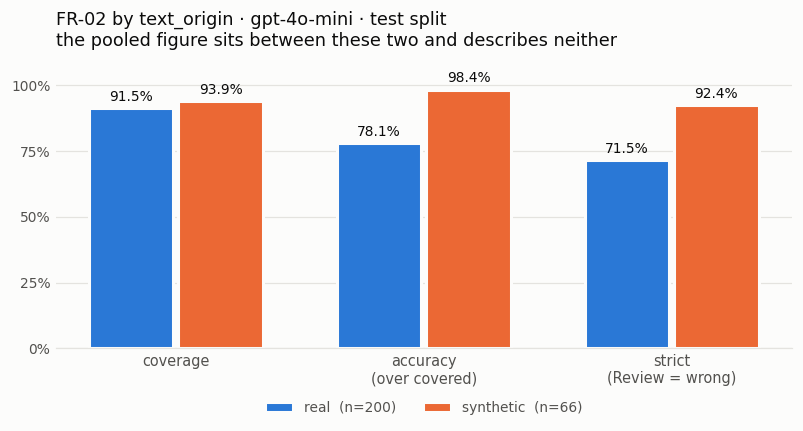

Every bar is directly labelled and the table above carries the same values.


In [19]:
metrics = ["coverage", "accuracy", "strict"]
groups = ["real", "synthetic"]
x = np.arange(len(metrics))
width = 0.34

fig, ax = plt.subplots(figsize=(7.4, 4.1))
for i, g in enumerate(groups):
    vals = [by_origin.loc[g, m] * 100 for m in metrics]
    # 2px surface gap between adjacent bars, via a small inset rather than a border.
    bars = ax.bar(x + (i - 0.5) * (width + 0.02), vals, width,
                  label=f"{g}  (n={int(by_origin.loc[g, 'n'])})",
                  color=SERIES[i], edgecolor=SURFACE, linewidth=2)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 1.6, f"{v:.1f}%",
                ha="center", va="bottom", fontsize=9, color=INK)

ax.set_xticks(x, ["coverage", "accuracy\n(over covered)", "strict\n(Review = wrong)"], fontsize=9.5)
ax.set_ylim(0, 108)
ax.set_yticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"], fontsize=9)
ax.set_title(f"FR-02 by text_origin · {MODEL_UNDER_TEST} · test split\n"
             "the pooled figure sits between these two and describes neither",
             fontsize=11.5, pad=12, loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2,
          fontsize=9, labelcolor=INK_2)       # below the plot: never over a bar
tidy(ax)
fig.tight_layout()
plt.show()

print("Every bar is directly labelled and the table above carries the same values.")

### What this does and does not license you to say

- **The real-email accuracy is the FR-02 result.** It is measured on genuine
  human-written mail, and it is the figure that describes how the product will behave on a
  user's inbox. If one categorisation number goes on a slide, this is the one.
- **The synthetic figure is close to ceiling and should never be quoted alone.** It is a
  single class of text written by the same model family that is now classifying it. It
  demonstrates that the pipeline works end to end; it does not demonstrate FR-02.
- **The pooled figure is an artefact of the mix.** It rises or falls with the proportion of
  generated rows in the set, independently of the classifier. That is why
  `eval/data/README.md` insists these columns never be collapsed, and why every table in
  this notebook reports the split.
- **`label_source` tells a subtler story than "human labels are better".** The rows the
  classifier scores *worst* on are the `human`-labelled ones, and the rows it scores best on
  (other than the generated class) are the weak `folder_heuristic` ones. That is not
  evidence that the weak labels are good. It is the expected consequence of how they are
  wrong: a label that says "everything in the inbox is Work" agrees with a classifier that
  over-predicts the majority class, so a shared bias inflates apparent accuracy. §10 shows
  that about a fifth of those `Work` labels are wrong, and that correcting them moves the
  number *up* — a measurement correction, not an improvement.

## 7 · Coverage vs accuracy

The classifier can abstain. That makes a single accuracy figure manipulable, so this section
reports the three numbers together and then demonstrates *why* — by showing what happens to
each when abstention is tuned.

There are two distinct reasons a row reaches `Review`, and the saved confidence column lets
them be separated: the model's confidence fell below the configured threshold, or the
evidence span it quoted could not be verified in the source. Only the first is tunable.

In [20]:
THRESHOLD = 0.7   # CLASSIFY_CONFIDENCE_THRESHOLD default, backend/config.py

print("The three numbers, together")
print("=" * 72)
print(f"  coverage             {overall['coverage']:6.1%}   "
      f"{overall['n'] - overall['reviewed']} of {overall['n']} rows answered")
print(f"  accuracy (covered)   {overall['accuracy']:6.1%}   correct, of those answered")
print(f"  strict               {overall['strict']:6.1%}   correct, of every row")
print()
print("  Each alone is misleading, and in a different direction:")
print("   - accuracy alone hides how often it declined to answer;")
print("   - coverage alone hides whether the answers were any good;")
print("   - strict alone punishes a safety feature working as designed, and cannot")
print("     distinguish 'wrong' from 'sent to a human on purpose'.")

reviewed = TEST[TEST["predicted"] == REVIEW]
low_conf = int((reviewed["confidence"] < THRESHOLD).sum())
print(f"\nThe Review bucket ({len(reviewed)} rows), decomposed")
print("=" * 72)
print(f"  confidence < {THRESHOLD} (below threshold)        {low_conf:3}")
print(f"  confidence >= {THRESHOLD} (evidence unverified)   {len(reviewed) - low_conf:3}")
print("\n  Only the first group is a threshold choice. The rest were abstentions because")
print("  the quoted evidence could not be found in the email, which no threshold sweep")
print("  can recover -- so the sweep below can only make the classifier MORE cautious,")
print("  never less. The saved file does not record the reason per row, so this split")
print("  is inferred from the confidence column and the configured threshold.")

The three numbers, together
  coverage              92.1%   245 of 266 rows answered
  accuracy (covered)    83.3%   correct, of those answered
  strict                76.7%   correct, of every row

  Each alone is misleading, and in a different direction:
   - accuracy alone hides how often it declined to answer;
   - coverage alone hides whether the answers were any good;
   - strict alone punishes a safety feature working as designed, and cannot
     distinguish 'wrong' from 'sent to a human on purpose'.

The Review bucket (21 rows), decomposed
  confidence < 0.7 (below threshold)          8
  confidence >= 0.7 (evidence unverified)    13

  Only the first group is a threshold choice. The rest were abstentions because
  the quoted evidence could not be found in the email, which no threshold sweep
  can recover -- so the sweep below can only make the classifier MORE cautious,
  never less. The saved file does not record the reason per row, so this split
  is inferred from the confide

In [21]:
print("Is the confidence score calibrated? (covered rows only)\n")
covered = TEST[TEST["predicted"] != REVIEW].copy()
rows = []
for conf, sub in covered.groupby("confidence"):
    rows.append({"confidence": conf, "n": len(sub),
                 "accuracy": (sub["expected"] == sub["predicted"]).mean()})
calib = pd.DataFrame(rows).set_index("confidence")
out = calib.copy(); out["accuracy"] = calib["accuracy"].map("{:.1%}".format)
print(out.to_string())
print("\nThe scores are coarse (a handful of discrete values) and NOT monotonic: the")
print("most-confident bucket is not the most accurate one. Confidence is usable as a")
print("cheap abstention trigger, but it is not a probability and must not be shown to")
print("a user as one.")

Is the confidence score calibrated? (covered rows only)

              n accuracy
confidence              
0.7           3     0.0%
0.8          20    10.0%
0.9         202    92.1%
1.0          20    80.0%

The scores are coarse (a handful of discrete values) and NOT monotonic: the
most-confident bucket is not the most accurate one. Confidence is usable as a
cheap abstention trigger, but it is not a probability and must not be shown to
a user as one.


In [22]:
sweep = []
for t in sorted(TEST["confidence"].unique()):
    sim = TEST.copy()
    sim.loc[sim["confidence"] < t, "predicted"] = REVIEW    # can only ADD abstentions
    m = score(sim["expected"], sim["predicted"])
    sweep.append({"threshold": t, "coverage": m["coverage"], "accuracy": m["accuracy"],
                  "strict": m["strict"], "macro-F1": m["macro_f1"]})
sweep = pd.DataFrame(sweep).set_index("threshold")

f = sweep.copy()
for c in ["coverage", "accuracy", "strict"]:
    f[c] = sweep[c].map("{:.1%}".format)
f["macro-F1"] = sweep["macro-F1"].map("{:.3f}".format)
print(f"Simulated abstention threshold (shipped value = {THRESHOLD})\n")
print(f.to_string())

best_acc = sweep["accuracy"].idxmax()
print(f"\naccuracy-over-covered peaks at threshold {best_acc}: "
      f"{sweep.loc[best_acc, 'accuracy']:.1%} "
      f"(+{(sweep.loc[best_acc, 'accuracy'] - overall['accuracy']) * 100:.1f} pp)")
print(f"  ... but strict accuracy there is {sweep.loc[best_acc, 'strict']:.1%} "
      f"({(sweep.loc[best_acc, 'strict'] - overall['strict']) * 100:+.1f} pp) "
      f"and coverage falls to {sweep.loc[best_acc, 'coverage']:.1%} "
      f"({(sweep.loc[best_acc, 'coverage'] - overall['coverage']) * 100:+.1f} pp).")
print("\nNo email was classified better. Rows were moved out of the denominator.")

Simulated abstention threshold (shipped value = 0.7)

          coverage accuracy strict macro-F1
threshold                                  
0.5          92.1%    83.3%  76.7%    0.793
0.7          92.1%    83.3%  76.7%    0.793
0.8          91.0%    84.3%  76.7%    0.798
0.9          83.5%    91.0%  75.9%    0.820
1.0           7.5%    80.0%   6.0%    0.103

accuracy-over-covered peaks at threshold 0.9: 91.0% (+7.7 pp)
  ... but strict accuracy there is 75.9% (-0.8 pp) and coverage falls to 83.5% (-8.6 pp).

No email was classified better. Rows were moved out of the denominator.


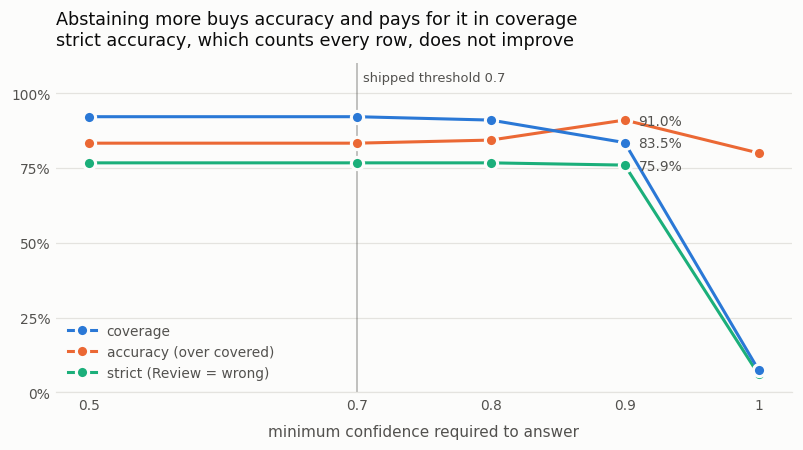

Simulated by raising the confidence floor on the SAVED predictions -- no model
calls. Lowering it cannot be simulated (see the decomposition above).


In [23]:
fig, ax = plt.subplots(figsize=(7.4, 4.2))
xs = sweep.index.to_numpy()
# Direct-label at the informative threshold (where the three separate), not at the
# degenerate right-hand end where two of them converge and the labels would collide.
label_at = float(sweep["accuracy"].idxmax())
for i, (col, label) in enumerate([("coverage", "coverage"),
                                  ("accuracy", "accuracy (over covered)"),
                                  ("strict", "strict (Review = wrong)")]):
    ys = sweep[col].to_numpy() * 100
    ax.plot(xs, ys, color=SERIES[i], linewidth=2, marker="o", markersize=8,
            markeredgecolor=SURFACE, markeredgewidth=2, label=label, zorder=3 - i * 0.1)
    y_at = sweep.loc[label_at, col] * 100
    ax.annotate(f"{y_at:.1f}%", (label_at, y_at), textcoords="offset points",
                xytext=(9, -3), fontsize=9, color=INK_2)

ax.axvline(THRESHOLD, color=INK_2, linewidth=1, linestyle="-", alpha=0.45, zorder=1)
ax.annotate(f"shipped threshold {THRESHOLD}", (THRESHOLD, 104), fontsize=8.5,
            color=INK_2, ha="left", xytext=(4, 0), textcoords="offset points")

ax.set_xlabel("minimum confidence required to answer", labelpad=8)
ax.set_ylim(0, 110)
ax.set_yticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"], fontsize=9)
ax.set_xticks(xs, [f"{v:g}" for v in xs], fontsize=9)
ax.set_title("Abstaining more buys accuracy and pays for it in coverage\n"
             "strict accuracy, which counts every row, does not improve",
             fontsize=11.5, pad=12, loc="left")
ax.legend(loc="lower left", fontsize=9, labelcolor=INK_2)
tidy(ax)
fig.tight_layout()
plt.show()

print("Simulated by raising the confidence floor on the SAVED predictions -- no model")
print("calls. Lowering it cannot be simulated (see the decomposition above).")

### Why quoting one of the three is misleading

The sweep is the proof. Raising the confidence floor lifts accuracy-over-covered by several
points while **strict accuracy does not improve and coverage drops sharply**. Nothing was
classified better; rows were removed from the denominator. A report that quoted only
accuracy-over-covered could show an improving classifier while the product answered fewer
and fewer emails — and at the extreme right of that chart the system answers almost nothing
and still reports a respectable accuracy.

Quoting only strict accuracy fails in the other direction: it treats a deliberate handover
to a human as though the system had confidently given a wrong answer, which is the one
outcome the design is trying to avoid.

So all three are reported, always, with the batch size — and the strict figure is the one
to use if a single conservative bound is needed.

## 8 · FR-01 / FR-03 — groundedness

Summarisation and drafting are not accuracy problems. A summary has no single correct
output, so there is nothing to be accurate *about*. What can be measured is whether the
system asserted anything the source email does not support: every number, amount, date,
time and proper noun in the output is checked against the preprocessed email, and an output
with zero unsupported claims is **grounded**.

    groundedness rate = outputs with zero ungrounded flags / outputs produced

Two rules from `evaluate_grounding.py` are load-bearing:

- **Production failures are never counted as grounded.** A summary that could not be
  produced is not a grounded summary. Folding those in would let a run that mostly crashed
  report a high score on the handful that survived, so they are reported separately.
- **The rate is meaningless without the claim count.** A groundedness rate computed over
  outputs that contain no numbers, dates or names would read 100% however badly the model
  behaved, because nothing was checked. The claims-per-output figure is what makes the rate
  mean anything, and it is treated as part of the result below.

In [24]:
def load_grounding(name):
    g = pd.read_csv(DATA / name, keep_default_na=False)
    # NB: g["flags"], never g.flags -- DataFrame.flags is a pandas attribute.
    g["is_grounded"] = g["grounded"].astype(str).str.strip().str.lower().eq("true")
    g["flag_count"] = g["flag_count"].astype(int)
    return g


GROUNDING = {"summarise": ("grounding_summarise.csv", "FR-01"),
             "draft": ("grounding_draft.csv", "FR-03")}
gr = {}
rows = []
for task, (fname, req) in GROUNDING.items():
    g = load_grounding(fname)
    gr[task] = g
    rows.append({
        "task": task, "requirement": req, "outputs produced": len(g),
        "grounded": int(g["is_grounded"].sum()),
        "flagged outputs": int((g["flag_count"] > 0).sum()),
        "total flags": int(g["flag_count"].sum()),
        "groundedness rate": g["is_grounded"].mean(),
    })
summary = pd.DataFrame(rows).set_index("task")
out = summary.copy()
out["groundedness rate"] = summary["groundedness rate"].map("{:.1%}".format)
print(out.to_string())

print("\nThe saved per-output files record only outputs that were PRODUCED. Attempted-but-")
print("failed rows (EmptyEmailError) are not in them, so the denominators above are")
print("'produced', which is the correct denominator for this rate -- but the attempted")
print("count and the failure count cannot be recovered from these files. They are in the")
print("run log in BENCHMARKS.md and are not restated here as if computed.")

          requirement  outputs produced  grounded  flagged outputs  total flags groundedness rate
task                                                                                             
summarise       FR-01                57        53                4            4             93.0%
draft           FR-03                38        37                1            1             97.4%

The saved per-output files record only outputs that were PRODUCED. Attempted-but-
failed rows (EmptyEmailError) are not in them, so the denominators above are
'produced', which is the correct denominator for this rate -- but the attempted
count and the failure count cannot be recovered from these files. They are in the
run log in BENCHMARKS.md and are not restated here as if computed.


In [25]:
for task, g in gr.items():
    print(f"{task} — by text_origin and category\n")
    rows = []
    for (origin, cat), sub in g.groupby(["text_origin", "category"]):
        rows.append({"text_origin": origin, "category": cat, "n": len(sub),
                     "grounded": sub["is_grounded"].mean()})
    t = pd.DataFrame(rows).set_index(["text_origin", "category"])
    show_t = t.copy(); show_t["grounded"] = t["grounded"].map("{:.1%}".format)
    print(show_t.to_string())
    for col in ["text_origin"]:
        agg = []
        for key, sub in g.groupby(col):
            agg.append({col: key, "n": len(sub), "grounded": f"{sub['is_grounded'].mean():.1%}"})
        print("\n" + pd.DataFrame(agg).set_index(col).to_string())
    print("\n" + "-" * 66 + "\n")

print("Both tasks are scored on the same balanced sample of classes, and in both the")
print("only flags fall on REAL email. The generated Studies rows are perfectly grounded,")
print("which is the same confound as §6: short, well-structured, model-written text is")
print("easier to summarise without inventing anything.")

summarise — by text_origin and category

                         n grounded
text_origin category               
real        Personal    13    84.6%
            Promotions  14   100.0%
            Work        15    86.7%
synthetic   Studies     15   100.0%

              n grounded
text_origin             
real         42    90.5%
synthetic    15   100.0%

------------------------------------------------------------------

draft — by text_origin and category

                         n grounded
text_origin category               
real        Personal     9   100.0%
            Promotions   9   100.0%
            Work        10    90.0%
synthetic   Studies     10   100.0%

              n grounded
text_origin             
real         28    96.4%
synthetic    10   100.0%

------------------------------------------------------------------

Both tasks are scored on the same balanced sample of classes, and in both the
only flags fall on REAL email. The generated Studies rows are perfectly 

In [26]:
print("What was actually flagged — the whole list, since there are few enough to read\n")
for task, g in gr.items():
    flagged = g[g["flag_count"] > 0]
    print(f"{task}: {len(flagged)} flagged output(s) of {len(g)}")
    for _, r in flagged.iterrows():
        print(f"   [{r['category']}/{r['text_origin']}] {r['subject'][:58]}")
        print(f"      -> {r['flags']}")
    reasons = {}
    for s in g["flags"]:
        for m in re.finditer(r"\(([^()]*)\)", str(s)):
            reasons[m.group(1)] = reasons.get(m.group(1), 0) + 1
    print(f"   flag kinds: {reasons or 'none'}\n")

print("Every flag is a name or a date the checker could not find in the source. Reading")
print("them matters: at these sample sizes one flag moves the rate by ~2 pp, so the rate")
print("is a summary of a list short enough to inspect, and it was inspected.")

What was actually flagged — the whole list, since there are few enough to read

summarise: 4 flagged output(s) of 57
   [Personal/real] Check out AOL Local Guide: Houston - What's Going On - Kin
      -> the AOL Local Guide for Kingwood Cove Golf Course (name does not appear in the source email)
   [Personal/real] Continental Schedule IAH SJU  1st class
      -> Call Crystal (name does not appear in the source email)
   [Work/real] NYISO Training
      -> the NYISO Market Orientation Course (name does not appear in the source email)
   [Work/real] RE: ISAS Meeting Agenda 2/14&15/2002
      -> January 17th (date does not appear in the source email)
   flag kinds: {'name does not appear in the source email': 3, 'date does not appear in the source email': 1}

draft: 1 flagged output(s) of 38
   [Work/real] NYISO Training
      -> the NYISO Market Orientation Course (name does not appear in the source email)
   flag kinds: {'name does not appear in the source email': 1}

Every flag is a na

### Claims checked per output — the honest position

This is the one metric DR-02 needs that **cannot be recomputed from the saved files.**

The claim count is derived from the *generated text* — `extract_typed_claims()` plus
`extract_proper_nouns()` over each summary or draft — and `evaluate_grounding.py --out`
persists only the per-row verdict, flag count and flag strings. The summaries and drafts
themselves were not saved. Recomputing the count would mean regenerating them, which is a
model call per row and is exactly what this notebook must not spend.

So the recorded run figures are **not restated here as computed values**. What can be
established from the saved data is a strict lower bound, plus a directly comparable
measure of how much checkable material the source emails contained — computed with the
same spaCy extractor the run used, which needs no API call.

In [27]:
print("Lower bound available from the saved files")
print("=" * 72)
for task, g in gr.items():
    flagged = int((g["flag_count"] > 0).sum())
    print(f"  {task:10} total flags = {int(g['flag_count'].sum()):3}  "
          f"=> at least {flagged} of {len(g)} outputs contained >=1 checkable claim")
print("\n  This bound is weak by construction: a grounded output is indistinguishable in")
print("  these files from an output with nothing to check. That ambiguity is precisely")
print("  what the claims-checked figure exists to remove, so the bound cannot substitute")
print("  for it. FIX: have evaluate_grounding.py write a `claims_checked` column (it")
print("  already computes the number in order to print it) -- then this is recoverable")
print("  from the CSV for every future run at zero cost.")

Lower bound available from the saved files
  summarise  total flags =   4  => at least 4 of 57 outputs contained >=1 checkable claim
  draft      total flags =   1  => at least 1 of 38 outputs contained >=1 checkable claim

  This bound is weak by construction: a grounded output is indistinguishable in
  these files from an output with nothing to check. That ambiguity is precisely
  what the claims-checked figure exists to remove, so the bound cannot substitute
  for it. FIX: have evaluate_grounding.py write a `claims_checked` column (it
  already computes the number in order to print it) -- then this is recoverable
  from the CSV for every future run at zero cost.


In [28]:
# Source-side claim density: how much checkable material was in the emails that were
# scored. Deterministic, local, no model call. This is NOT the output-side claims-checked
# figure -- it is an upper reference for it, and is labelled as such.
claim_density = None
try:
    from backend.orchestrator import grounding as gmod
    gmod._load_spacy()
    backend_name = gmod.ENTITY_BACKEND
    print(f"entity backend: {backend_name}"
          f"{'  (same extractor the recorded run used)' if backend_name == 'spacy' else ''}")
    if backend_name != "spacy":
        print("  WARNING: spaCy unavailable; the weaker capitalisation heuristic is in use,")
        print("  so the counts below are NOT comparable to the recorded run.")

    rows = []
    for task, g in gr.items():
        sub = ds[ds["id"].isin(set(g["id"]))]
        counts = []
        for _, r in sub.iterrows():
            text = f"{r['subject']}\n{r['body']}"
            counts.append(len(gmod.extract_typed_claims(text))
                          + len(gmod.extract_proper_nouns(text)))
        counts = np.array(counts)
        rows.append({"task": task, "emails": len(counts),
                     "checkable claims in SOURCE": int(counts.sum()),
                     "per email": counts.mean(),
                     "median": float(np.median(counts)),
                     "emails with none": int((counts == 0).sum())})
    claim_density = pd.DataFrame(rows).set_index("task")
    out = claim_density.copy()
    out["per email"] = claim_density["per email"].map("{:.1f}".format)
    print()
    print(out.to_string())
    print("\nRead this as: the emails being summarised are dense with checkable material,")
    print("so a summary of them has ample opportunity to fabricate. That is the premise")
    print("the groundedness rate rests on. It is NOT the claims-per-OUTPUT figure -- a")
    print("summary contains a subset of its source's claims -- and it must not be quoted")
    print("as one. The output-side figure is in the run log and is not reproduced here.")
except Exception as exc:
    print(f"Source-side claim density unavailable ({type(exc).__name__}: {exc}).")
    print("This cell is optional; it needs backend.orchestrator.grounding and the spaCy")
    print("model en_core_web_sm. No metric reported elsewhere depends on it.")

entity backend: spacy  (same extractor the recorded run used)



           emails  checkable claims in SOURCE per email  median  emails with none
task                                                                             
summarise      57                         645      11.3     7.0                 1
draft          38                         455      12.0     7.0                 1

Read this as: the emails being summarised are dense with checkable material,
so a summary of them has ample opportunity to fabricate. That is the premise
the groundedness rate rests on. It is NOT the claims-per-OUTPUT figure -- a
summary contains a subset of its source's claims -- and it must not be quoted
as one. The output-side figure is in the run log and is not reproduced here.


### What a groundedness flag does and does not mean

Both directions have to be stated, because the metric is asymmetric and easy to over-read.

- **A flag is evidence of a problem, not proof of one.** It means a token in the output is
  not in the source. A legitimate paraphrase can flag — "next Friday" for a date written
  out in full, or a name the model reasonably expanded. The flagged rows listed above are
  exactly this kind of judgement call, which is why the list is short enough to read and was
  read.
- **Zero flags does not mean the summary is true.** It means nothing *checkable* is
  missing. A summary can be grounded in every name and number and still misrepresent the
  email's point entirely, and this metric will not notice.

The measured rates also reflect three verifier corrections made during evaluation — the
evidence comparison ignoring punctuation, and proper-noun handling stripping leading
articles, possessives and salutations. Each was found by inspecting flagged output,
confirmed as a false positive and fixed narrowly, with regression tests proving genuine
fabrications are still caught. Those changes raised the measured numbers by making the
measurement correct, not by weakening the check — but they are a reminder that a
groundedness figure is only meaningful with its verifier version and entity backend stated
alongside it.

## 9 · `gpt-4o` vs `gpt-4o-mini`, like for like

Both files are saved, cover the same held-out rows, and differ only in the model — so the
comparison costs nothing to recompute and it is the evidence for the shipped configuration.

In [29]:
FOURO = preds["test_preds.csv"]
assert set(FOURO["id"]) == set(TEST["id"]), "the two test files do not cover the same rows"
print(f"same {len(TEST)} held-out rows, same prompt, model is the only difference\n")

cmp_rows = {}
for name, df in [("gpt-4o-mini", TEST), ("gpt-4o", FOURO)]:
    m = score(df["expected"], df["predicted"])
    cmp_rows[name] = {"coverage": m["coverage"], "accuracy": m["accuracy"],
                      "strict": m["strict"], "macro-F1": m["macro_f1"]}
cmp = pd.DataFrame(cmp_rows).T
diff = (cmp.loc["gpt-4o"] - cmp.loc["gpt-4o-mini"])

f = cmp.copy()
for c in ["coverage", "accuracy", "strict"]:
    f[c] = cmp[c].map("{:.1%}".format)
f["macro-F1"] = cmp["macro-F1"].map("{:.3f}".format)
print(f.to_string())
print("\ndifference (gpt-4o minus gpt-4o-mini), in percentage points")
print("  " + "   ".join(f"{k} {v * 100:+.1f}" for k, v in diff.items() if k != "macro-F1")
      + f"   macro-F1 {diff['macro-F1']:+.3f}")

print("\nBy text_origin, the comparison that actually matters (§6)\n")
rows, origin_metrics = [], {}
for name, df in [("gpt-4o-mini", TEST), ("gpt-4o", FOURO)]:
    for origin, sub in df.groupby("text_origin"):
        m = score(sub["expected"], sub["predicted"])
        origin_metrics[(name, origin)] = m
        rows.append({"model": name, "text_origin": origin, "n": m["n"],
                     "coverage": f"{m['coverage']:.1%}", "accuracy": f"{m['accuracy']:.1%}",
                     "strict": f"{m['strict']:.1%}", "macro-F1": f"{m['macro_f1']:.3f}"})
print(pd.DataFrame(rows).set_index(["model", "text_origin"]).to_string())

NOISE_PP = 0.5   # the documented run-to-run band, §10.2
print(f"\nWhich of these gaps survive the ~{NOISE_PP} pp run-to-run noise band (§10.2)?\n")
for metric in ["coverage", "accuracy", "strict"]:
    pooled_gap = (cmp.loc["gpt-4o", metric] - cmp.loc["gpt-4o-mini", metric]) * 100
    real_gap = (origin_metrics[("gpt-4o", "real")][metric]
                - origin_metrics[("gpt-4o-mini", "real")][metric]) * 100
    verdict = "yes" if abs(real_gap) > NOISE_PP else "NO -- inside the noise"
    print(f"  {metric:9} pooled {pooled_gap:+5.1f} pp   on REAL email {real_gap:+5.1f} pp"
          f"   survives on real email: {verdict}")
print("\n  The sign flip on strict accuracy is the finding: pooled, gpt-4o looks slightly")
print("  ahead; on real email -- the only rows that test FR-02 -- it is slightly BEHIND,")
print("  because it abstains considerably more there. Its pooled advantage comes from the")
print("  generated class, where it scores 100% and mini does not.")

same 266 held-out rows, same prompt, model is the only difference

            coverage accuracy strict macro-F1
gpt-4o-mini    92.1%    83.3%  76.7%    0.793
gpt-4o         89.1%    86.9%  77.4%    0.814

difference (gpt-4o minus gpt-4o-mini), in percentage points
  coverage -3.0   accuracy +3.7   strict +0.8   macro-F1 +0.021

By text_origin, the comparison that actually matters (§6)

                           n coverage accuracy  strict macro-F1
model       text_origin                                        
gpt-4o-mini real         200    91.5%    78.1%   71.5%    0.749
            synthetic     66    93.9%    98.4%   92.4%    0.961
gpt-4o      real         200    85.5%    81.9%   70.0%    0.755
            synthetic     66   100.0%   100.0%  100.0%    1.000

Which of these gaps survive the ~0.5 pp run-to-run noise band (§10.2)?

  coverage  pooled  -3.0 pp   on REAL email  -6.0 pp   survives on real email: yes
  accuracy  pooled  +3.7 pp   on REAL email  +3.7 pp   survives on rea

The stronger model buys a few points of accuracy-over-covered and **very little on strict
accuracy**, because it also abstains more often — so `gpt-4o-mini` answers more emails. At
roughly 15× the cost per call and a lower rate limit, that is not a trade this project can
justify under a \$5/week budget. The shipped configuration stays on `gpt-4o-mini`, and this
table is why.

Two cautions on reading it, both of which make the conclusion *more* secure rather than
less:

- **The pooled strict-accuracy gap is small and its exact size is noise-dependent.** It
  computes here from run 9; against run 8 — the same model, prompt and rows, executed twice
  — `BENCHMARKS.md` records a smaller gap still. A difference that changes materially
  depending on which of two identical runs you compare against is not a difference to spend
  15× on. This is §10.2 in action, not a discrepancy to resolve.
- **On real email, `gpt-4o` is behind on strict accuracy.** Split by `text_origin`, its
  pooled advantage turns out to come from the generated `Studies` rows, where it scores
  100%. On the real Enron mail — the only rows that test FR-02 — it abstains much more and
  ends up marginally *worse* per row. The cheaper model is the better choice on the measure
  and the subset that matter, which is a stronger claim than "close enough for the money".

One correction is worth recording, because it changed a conclusion. On the **dev** split the
same comparison looked like a large win for the stronger model, and it was reported
internally as the model being the dominant factor. It was not: the same `gpt-4o-mini`
configuration scored about ten points higher on test than on dev, a swing between splits
larger than the difference between the two models. Most of the apparent dev gap was split
difficulty. That is why only the like-for-like held-out run is quoted — and, given §2, why
the unreconciled `dev_preds.csv` is not used here at all.

## 10 · Limitations

Every figure above is honest about what it measures and fragile in ways a reader cannot see
from the number alone. These are the four that matter most.

### 10.1 · The `Work` labels are weak, and about a fifth of them are wrong

The `Work` rows carry `label_source = folder_heuristic` — the label means only "it was in
the inbox". All of them were read by hand, and a substantial minority are not Work at all:
spam, club flyers, fantasy-football threads, a note from a spouse. Corrections are **staged
and not applied**; `dataset.csv` still carries the original labels, so the figures above are
measured against labels known to contain errors.

In [30]:
review = pd.read_csv(DATA / "review_work.csv", keep_default_na=False)
work_rows = ds[(ds["category"] == "Work") & (ds["label_source"] == "folder_heuristic")]

print(f"staged review file rows          {len(review)}")
print(f"dataset Work/folder_heuristic    {len(work_rows)}")
print(f"review covers exactly those ids  {set(review['id']) == set(work_rows['id'])}")
print(f"rows marked verified by a human  {int((review['verified'].astype(str).str.strip() != '').sum())}"
      "   <-- nothing has been confirmed, so nothing has been applied")
print()
proposed = review["proposed_category"].value_counts()
wrong = int((review["proposed_category"] != "Work").sum())
print("Proposed category for the 'Work' rows")
print(proposed.to_frame("rows").to_string())
print(f"\nnot Work: {wrong} of {len(review)} = {wrong / len(review):.1%} of the class")
print(f"as a share of the whole dataset: {wrong / len(ds):.1%}")

staged review file rows          120
dataset Work/folder_heuristic    120
review covers exactly those ids  True
rows marked verified by a human  0   <-- nothing has been confirmed, so nothing has been applied

Proposed category for the 'Work' rows
                   rows
proposed_category      
Work                 93
Promotions           13
Personal             13
Studies               1

not Work: 27 of 120 = 22.5% of the class
as a share of the whole dataset: 5.6%


In [31]:
# How much of the measured error is label error? Indicative only.
m = TEST.merge(review[["id", "proposed_category"]], on="id", how="left")
in_test = m["proposed_category"].notna()
changed = in_test & (m["proposed_category"] != m["expected"])

print(f"staged corrections landing in the test split: {int(changed.sum())}")
print(m.loc[changed, "proposed_category"].value_counts().to_frame("rows").to_string())
print(f"\nof those, the classifier's prediction ALREADY matched the staged label: "
      f"{int((m.loc[changed, 'predicted'] == m.loc[changed, 'proposed_category']).sum())}"
      f" of {int(changed.sum())}")

print("\nHow much of the confusion matrix's one-way Work outflow is label error?")
for target in ["Promotions", "Personal"]:
    cell = m[(m["expected"] == "Work") & (m["predicted"] == target)]
    agree = int((cell["proposed_category"] == target).sum())
    print(f"  Work -> {target:11} {len(cell):3} rows, of which {agree} are staged as "
          f"{target} anyway ({agree / len(cell):.0%} of the cell)")

sim = m.copy()
sim.loc[changed, "expected"] = sim.loc[changed, "proposed_category"]
before, after = score(m["expected"], m["predicted"]), score(sim["expected"], sim["predicted"])
print("\nIndicative sensitivity — NOT a result\n")
print(f"  as labelled today   {triple(before)}")
print(f"  with staged labels  {triple(after)}")
print(f"  accuracy {(after['accuracy'] - before['accuracy']) * 100:+.1f} pp   "
      f"strict {(after['strict'] - before['strict']) * 100:+.1f} pp   "
      f"macro-F1 {after['macro_f1'] - before['macro_f1']:+.3f}")

staged corrections landing in the test split: 11
                   rows
proposed_category      
Promotions            6
Personal              5

of those, the classifier's prediction ALREADY matched the staged label: 7 of 11

How much of the confusion matrix's one-way Work outflow is label error?
  Work -> Promotions    8 rows, of which 4 are staged as Promotions anyway (50% of the cell)
  Work -> Personal      5 rows, of which 3 are staged as Personal anyway (60% of the cell)

Indicative sensitivity — NOT a result

  as labelled today   n=266   coverage= 92.1%  accuracy(covered)= 83.3%  strict= 76.7%  macro-F1=0.793
  with staged labels  n=266   coverage= 92.1%  accuracy(covered)= 85.3%  strict= 78.6%  macro-F1=0.814
  accuracy +2.0 pp   strict +1.9 pp   macro-F1 +0.021


**Read that sensitivity carefully.** The staged labels are **proposals awaiting human
verification**, and the `verified` column above is empty. They must not be reported as a
result, for a reason the project has already written down: model-proposed labels used to
grade a model are not an evaluation. The two share failure modes, so the emails that
confuse the classifier are disproportionately the ones that confused the labeller, and
measured accuracy comes out too high. The number above is biased upward by exactly that
mechanism and is shown only to size the problem.

What it does establish is the **direction**: between half and two-thirds of the one-way
`Work → Promotions` and `Work → Personal` flow in the §5 matrix consists of rows the review
proposes relabelling to the very class the classifier predicted. Those are cases where the classifier was right
and the ground truth was wrong. So the reported accuracy **understates** the classifier, and
when the corrections are verified and applied the figure should be expected to rise — as a
**measurement correction, not a capability improvement**, and it must be described that way
in the report. The same failure has already been corrected once in the `Personal` class,
where the folder heuristic was right about one time in four.

### 10.2 · Run-to-run variance: anything under about half a point is noise

`temperature=0` is not determinism. Batch composition changes what context each email is
classified alongside, and the provider does not guarantee identical output for identical
input. The project has the direct evidence: two runs of the **same model, same prompt, same
rows, same batch size** differ by a few tenths of a point on every metric.

This notebook's §2 reconciliation is itself an instance of that. The saved file reproduces
one of those two runs and not the other, and the headline accuracy computed here differs
from the document's by 0.3 pp with no change to the model, the prompt or the data.

The consequences are binding on how these numbers may be quoted:

- **Do not quote more than one decimal place**, and treat differences under ~0.5 pp as
  noise. Several of the per-class F1 differences in §4 are inside that band.
- **State the batch size** with any figure (`--batch-size 20` throughout).
- **Every figure here is a single run.** None has a confidence interval, because repeated
  runs cost budget. §9 shows what that costs in practice: the mini/4o gap on covered
  accuracy is comfortably larger than this band, but the strict-accuracy gap sits close
  enough to it that its size depends on which of two identical runs is used as the baseline
  — so the model decision is argued from the real-email split, where the sign of the gap is
  stable, rather than from the pooled strict figure alone.

### 10.3 · ROUGE is not reported, and that is deliberate

In [32]:
# The ROUGE argument, checked against the data rather than asserted. DATASET_COLUMNS is
# the schema as stored on disk, so the `split` column derived in §2 is not counted here.
candidates = [c for c in DATASET_COLUMNS
              if re.search(r"summar|referenc|abstract|gold|target|gist", c, re.I)]
print(f"columns in dataset.csv: {DATASET_COLUMNS}")
print(f"columns that could serve as a reference summary: {candidates or 'NONE'}")
print(f"\nrows in DR-01: {len(ds)}   reference summaries available: 0")
print("\nROUGE scores n-gram overlap against a reference summary. There is no reference")
print("summary in this dataset and no column that could stand in for one, so ROUGE is")
print("not merely unreported here -- it is not computable on DR-01 at all. Producing it")
print(f"would first require hand-writing {len(ds)} reference summaries.")

columns in dataset.csv: ['id', 'provenance', 'text_origin', 'label_source', 'label_confidence', 'category', 'subject', 'body', 'sender', 'received_at', 'source_ref']
columns that could serve as a reference summary: NONE

rows in DR-01: 480   reference summaries available: 0

ROUGE scores n-gram overlap against a reference summary. There is no reference
summary in this dataset and no column that could stand in for one, so ROUGE is
not merely unreported here -- it is not computable on DR-01 at all. Producing it
would first require hand-writing 480 reference summaries.


And it would still not answer the question. ROUGE cannot detect hallucination: a fluent,
wholly fabricated summary that reuses the email's vocabulary scores *well*, and that is
precisely the failure this project exists to catch. So the work would be large, the number
would be weak, and the risk would remain unmeasured. Groundedness is reported instead
because it addresses the actual risk. If ROUGE appears in the RTM, the cell above is the
work it implies, and §8 is the metric that was chosen in its place.

### 10.4 · Things these numbers cannot tell you

- **Sample size.** The test split is 266 rows and the grounding samples are smaller still —
  around 57 summaries and 38 drafts. At that size a single output moves a groundedness rate
  by roughly two points, so those rates are indicative, not precise. They are quoted with
  their denominators throughout for that reason.
- **The `Personal` class is a defined subpopulation, not a random sample.** Its rows were
  recovered from the Enron archive by *structural* signals — consumer mail domain, few
  recipients, no bulk sender, shallow forward chain — deliberately not keyword signals,
  since selecting personal mail by the words that make it obviously personal would produce a
  class of easy cases and flatter the classifier. The consequence is that the class means
  *personal mail arriving at a corporate inbox, usually from an outside address*. Personal
  mail between two colleagues on internal addresses is systematically under-represented,
  because the domain signal cannot see it. `Personal` being the weakest class in §4 should
  be read with that in mind.
- **One corpus, one era.** Three of the four classes are Enron mail from 2001–02. Nothing
  here measures performance on modern HTML marketing mail, on non-English mail, or on any
  individual user's inbox.
- **`dev_preds.csv` does not reconcile with any recorded run (§2).** No figure here depends
  on it, but it is an open data-hygiene item: either the run belongs in the history table or
  the file should be regenerated or removed.
- **Not measured at all.** FR-05 voice-intent dispatch accuracy and NFR-01 latency (p95) are
  outside DR-02 and are not in this notebook. Neither should be quoted from it.

## 11 · DR-02 coverage

Every item the RTM names, and where it is computed. The cell below rebuilds each figure
from the same saved files, so the checklist is a computed summary rather than a claim.

In [33]:
real_row = by_origin.loc["real"]
synth_row = by_origin.loc["synthetic"]

print(f"DR-02 — labelled dataset as ground truth · {MODEL_UNDER_TEST} · "
      f"held-out test split, n={overall['n']}, batch size 20, temperature 0")
print("=" * 86)
items = [
    ("ground-truth dataset",  f"{len(ds)} rows, {len(CLASSES)} classes, "
                              f"{int((ds['text_origin'] == 'real').sum())} real / "
                              f"{int((ds['text_origin'] == 'synthetic').sum())} synthetic", "§1"),
    ("accuracy (covered)",    f"{overall['accuracy']:.1%}", "§4"),
    ("accuracy (strict)",     f"{overall['strict']:.1%}", "§4, §7"),
    ("coverage",              f"{overall['coverage']:.1%}", "§4, §7"),
    ("precision, per class",  ", ".join(f"{k} {v['precision']:.1%}"
                                        for k, v in overall["per_class"].items()), "§4"),
    ("recall, per class",     ", ".join(f"{k} {v['recall']:.1%}"
                                        for k, v in overall["per_class"].items()), "§4"),
    ("F1, per class",         ", ".join(f"{k} {v['f1']:.3f}"
                                        for k, v in overall["per_class"].items()), "§4"),
    ("macro-F1",              f"{overall['macro_f1']:.3f}", "§4"),
    ("confusion matrix",      f"{cm.shape[0]}x{cm.shape[1]} (4 classes + Review), table and plot", "§5"),
    ("accuracy on REAL email", f"{real_row['accuracy']:.1%}  (n={int(real_row['n'])})  "
                               "<-- the FR-02 figure to quote", "§6"),
    ("accuracy on synthetic",  f"{synth_row['accuracy']:.1%}  (n={int(synth_row['n'])})  "
                               "not a capability result", "§6"),
    ("FR-01 groundedness",    f"{summary.loc['summarise', 'groundedness rate']:.1%} "
                              f"({int(summary.loc['summarise', 'grounded'])}/"
                              f"{int(summary.loc['summarise', 'outputs produced'])} produced)", "§8"),
    ("FR-03 groundedness",    f"{summary.loc['draft', 'groundedness rate']:.1%} "
                              f"({int(summary.loc['draft', 'grounded'])}/"
                              f"{int(summary.loc['draft', 'outputs produced'])} produced)", "§8"),
    ("claims checked / output", "NOT recomputable from the saved files -- see §8", "§8"),
    ("ROUGE",                 "not computable on DR-01: 0 reference summaries", "§10.3"),
]
for name, value, where in items:
    print(f"  {name:24} {where:8} {value}")

print("\n" + "=" * 86)
print("Single-run figures, no confidence intervals. Differences under ~0.5 pp are noise")
print("(§10.2). Measured against labels with a known, unapplied correction pending for")
print("the Work class, which biases the reported figure DOWNWARD (§10.1).")
print("\nIf one number goes on a slide, it is the real-email accuracy above, with its n.")

DR-02 — labelled dataset as ground truth · gpt-4o-mini · held-out test split, n=266, batch size 20, temperature 0
  ground-truth dataset     §1       480 rows, 4 classes, 360 real / 120 synthetic
  accuracy (covered)       §4       83.3%
  accuracy (strict)        §4, §7   76.7%
  coverage                 §4, §7   92.1%
  precision, per class     §4       Work 81.4%, Personal 80.0%, Promotions 76.9%, Studies 93.8%
  recall, per class        §4       Work 75.0%, Personal 58.1%, Promotions 80.6%, Studies 92.4%
  F1, per class            §4       Work 0.781, Personal 0.673, Promotions 0.787, Studies 0.931
  macro-F1                 §4       0.793
  confusion matrix         §5       4x5 (4 classes + Review), table and plot
  accuracy on REAL email   §6       78.1%  (n=200)  <-- the FR-02 figure to quote
  accuracy on synthetic    §6       98.4%  (n=66)  not a capability result
  FR-01 groundedness       §8       93.0% (53/57 produced)
  FR-03 groundedness       §8       97.4% (37/38 produc